In [3]:
!mamba install pandas
!mamba install seaborn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 3.8275999999940393 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.2                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2026.2                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   
mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn
Channels: emscripten-forge, conda-forge

Solving environ

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded ✓")

All libraries loaded ✓


In [5]:
df_2024 = pd.read_csv('Startup_funding_2024.csv')
df_2026 = pd.read_csv('Recently Funded Startups In India 2026.csv')

print("2024 shape:", df_2024.shape)
print("2026 shape:", df_2026.shape)

2024 shape: (436, 6)
2026 shape: (100, 7)


In [6]:
# Rename columns to standard names
df_2024.rename(columns={
    'Company': 'name',
    'Sector': 'sector',
    'Headquarters': 'city',
    'Amount': 'funding_amount',
    'Funding_Round_Type': 'funding_type',
    'Lead_Investors': 'investors'
}, inplace=True)

# Add year column
df_2024['year'] = 2024

# Clean funding amount — remove $, commas, convert to float
df_2024['funding_amount'] = df_2024['funding_amount'].astype(str)
df_2024['funding_amount'] = df_2024['funding_amount'].str.replace('$', '', regex=False)
df_2024['funding_amount'] = df_2024['funding_amount'].str.replace(',', '', regex=False)
df_2024['funding_amount'] = df_2024['funding_amount'].str.replace('M', 'e6', regex=False)
df_2024['funding_amount'] = df_2024['funding_amount'].str.replace('B', 'e9', regex=False)
df_2024['funding_amount'] = pd.to_numeric(df_2024['funding_amount'], errors='coerce')

# Drop nulls in key columns
df_2024.dropna(subset=['sector', 'funding_amount', 'funding_type'], inplace=True)

# Strip whitespace
df_2024['sector'] = df_2024['sector'].str.strip()
df_2024['funding_type'] = df_2024['funding_type'].str.strip()
df_2024['city'] = df_2024['city'].str.strip()

print("2024 cleaned shape:", df_2024.shape)
print(df_2024.head(3))

2024 cleaned shape: (11, 7)
           name                     sector       city  funding_amount  \
118   CADRE ODR  Online Dispute Resolution  Bengaluru        200000.0   
150       Induz              Data Security  Hyderabad        780000.0   
151  30 Sundays            AI Travel Agent    Gurgaon        770000.0   

          funding_type                                          investors  \
118       Pre-Series A  Aprameya Radhakrishna, Murali Subramanian, Ram...   
150  New Funding Round            YourNest Venture Capital, SanchiConnect   
151     Pre-seed Round  Infoedge Ventures, First Cheque, Eximius, Misf...   

     year  
118  2024  
150  2024  
151  2024  


In [7]:
# Rename columns
df_2026.rename(columns={
    'Name': 'name',
    'Industry': 'sector',
    'Funding Amount (USD)': 'funding_amount',
    'Funding Type': 'funding_type',
    'Website': 'website',
    'Last Funding Date': 'date'
}, inplace=True)

# Add year column
df_2026['year'] = 2026

# Clean funding amount
df_2026['funding_amount'] = df_2026['funding_amount'].astype(str)
df_2026['funding_amount'] = df_2026['funding_amount'].str.replace('$', '', regex=False)
df_2026['funding_amount'] = df_2026['funding_amount'].str.replace(',', '', regex=False)
df_2026['funding_amount'] = pd.to_numeric(df_2026['funding_amount'], errors='coerce')

# 2026 has multiple sectors per startup — take the first one as primary
df_2026['sector'] = df_2026['sector'].str.split(',').str[0].str.strip()

# Drop nulls
df_2026.dropna(subset=['funding_amount', 'funding_type'], inplace=True)

# No city column in 2026 — add empty
df_2026['city'] = 'Unknown'

print("2026 cleaned shape:", df_2026.shape)
print(df_2026.head(3))

2026 cleaned shape: (87, 9)
              name             website      sector Country  funding_amount  \
0        EarthSync        earthsync.io      Energy   India       1000000.0   
1        4baseCare       4basecare.com  Healthcare   India       9803025.0   
2  Cava Athleisure  cavaathleisure.com     Fashion   India       4353085.0   

  funding_type           date  year     city  
0     Pre-Seed  February 2026  2026  Unknown  
1     Series B  February 2026  2026  Unknown  
2     Series A  February 2026  2026  Unknown  


In [8]:
# Keep only common columns
common_cols = ['name', 'sector', 'city', 'funding_amount', 'funding_type', 'year']

df_2024_clean = df_2024[common_cols]
df_2026_clean = df_2026[common_cols]

# Combine
df = pd.concat([df_2024_clean, df_2026_clean], ignore_index=True)

print("Combined shape:", df.shape)
print("Years:", df['year'].unique())
df.head()

Combined shape: (98, 6)
Years: [2024 2026]


,name,sector,city,funding_amount,funding_type,year
0,CADRE ODR,Online Dispute Resolution,Bengaluru,200000.0,Pre-Series A,2024
1,Induz,Data Security,Hyderabad,780000.0,New Funding Round,2024
2,30 Sundays,AI Travel Agent,Gurgaon,770000.0,Pre-seed Round,2024
3,Viraa Care,Healthtech,Chandigarh,108000.0,Pre-seed Round,2024
4,WishNew Wellness,Wellness,New Delhi,250000.0,Angel Round,2024


In [9]:
# This is your unique angle — identifying AI startups across both years
ai_keywords = ['artificial intelligence', 'ai', 'machine learning', 'ml', 
               'deep learning', 'nlp', 'data', 'analytics']

df['is_ai'] = df['sector'].str.lower().str.contains(
    '|'.join(ai_keywords), na=False
)

print("AI startups:", df['is_ai'].sum())
print("Non-AI startups:", (~df['is_ai']).sum())

AI startups: 8
Non-AI startups: 90


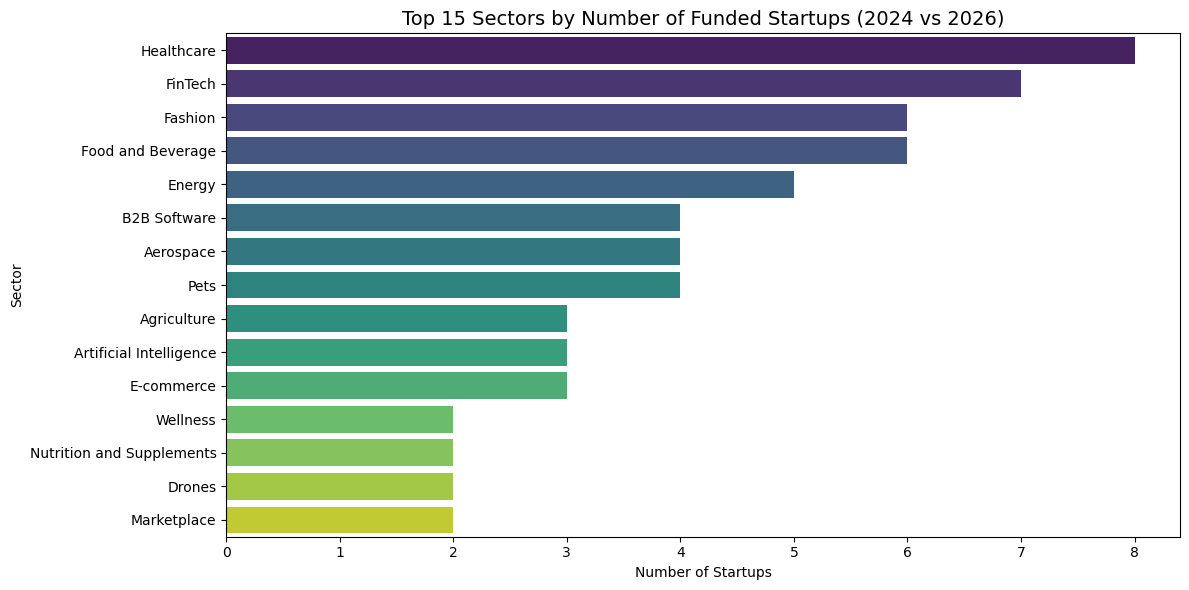

Saved ✓


In [10]:
plt.figure(figsize=(12, 6))

top_sectors = df['sector'].value_counts().head(15)

sns.barplot(x=top_sectors.values, y=top_sectors.index, palette='viridis')
plt.title('Top 15 Sectors by Number of Funded Startups (2024 vs 2026)', fontsize=14)
plt.xlabel('Number of Startups')
plt.ylabel('Sector')
plt.tight_layout()
plt.savefig('top_sectors.png', dpi=150)
plt.show()
print("Saved ✓")

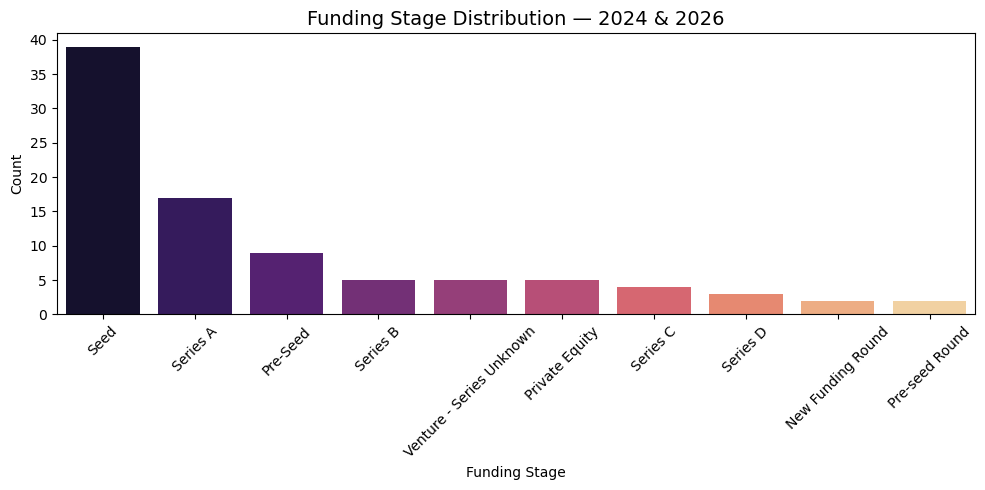

Saved ✓


In [12]:
plt.figure(figsize=(10, 5))

stage_counts = df['funding_type'].value_counts().head(10)

sns.barplot(x=stage_counts.index, y=stage_counts.values, palette='magma')
plt.title('Funding Stage Distribution — 2024 & 2026', fontsize=14)
plt.xlabel('Funding Stage')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('funding_stages.png', dpi=150)
plt.show()
print("Saved ✓")

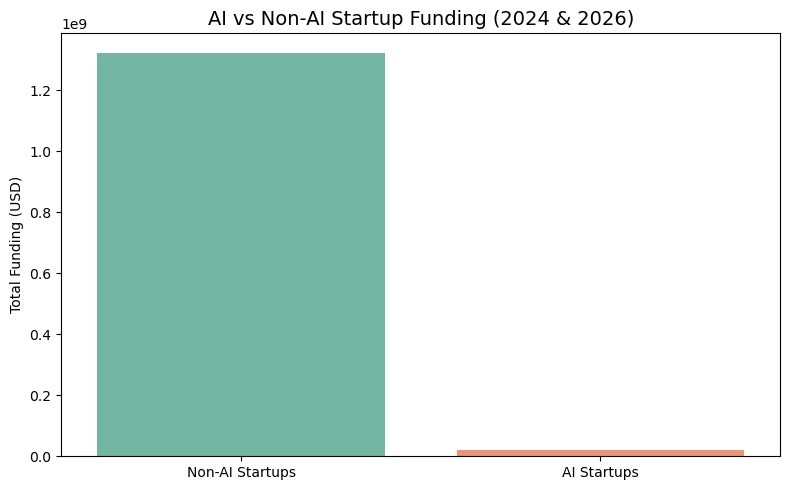

Saved ✓


In [13]:
plt.figure(figsize=(8, 5))

ai_funding = df.groupby('is_ai')['funding_amount'].sum().reset_index()
ai_funding['label'] = ai_funding['is_ai'].map({True: 'AI Startups', False: 'Non-AI Startups'})

sns.barplot(x='label', y='funding_amount', data=ai_funding, palette='Set2')
plt.title('AI vs Non-AI Startup Funding (2024 & 2026)', fontsize=14)
plt.xlabel('')
plt.ylabel('Total Funding (USD)')
plt.tight_layout()
plt.savefig('ai_vs_nonai.png', dpi=150)
plt.show()
print("Saved ✓")

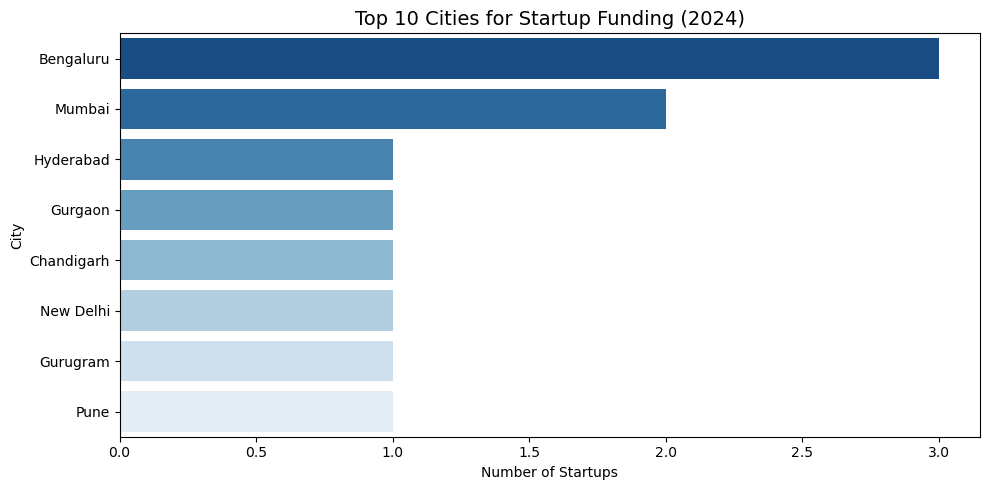

Saved ✓


In [14]:
plt.figure(figsize=(10, 5))

city_data = df[df['city'] != 'Unknown']
top_cities = city_data['city'].value_counts().head(10)

sns.barplot(x=top_cities.values, y=top_cities.index, palette='Blues_r')
plt.title('Top 10 Cities for Startup Funding (2024)', fontsize=14)
plt.xlabel('Number of Startups')
plt.ylabel('City')
plt.tight_layout()
plt.savefig('top_cities.png', dpi=150)
plt.show()
print("Saved ✓")

In [15]:
df.to_csv('india_startup_funding_clean.csv', index=False)
print("Clean dataset exported ✓")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Clean dataset exported ✓
Shape: (98, 7)
Columns: ['name', 'sector', 'city', 'funding_amount', 'funding_type', 'year', 'is_ai']
